# Spectral Analysis of Sentinel-2 image

Sentinel-2 is an Earth-observation mission funded by the European Space Agency that acquires high-resolution “images” of the Earth’s surface using a multispectral optical sensor. The constellation currently consists of three satellites (Sentinel-2A, -2B, and -2C), beginning with the launch of Sentinel-2A in 2015. Sentinel-2 is a passive optical system: it does not emit radiation but instead relies on sunlight reflected from the Earth’s surface to form images.

In the previous practical sessions, we focused on one-dimensional temporal signals. Here, we extend the signal-processing tools learned so far so they can be applied to two-dimensional spatial fields.


In [1]:
import warnings
warnings.filterwarnings('ignore') 
# if /!\Error/!\ comment the two lines above

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
ds_satellite = xr.open_dataset('./data/S2_imag.nc') # Load the image (Netcdf format, open it with xarray)

In [107]:
##########
# ---  The sub-domain for the 2D spectral analysis
##########
min_longitude, max_longitude = 332.2, 332.4
min_latitude, max_latitude = 39.3, 39.1448

##########
# --- Transect for the plot below
##########
longitude_transect_start = 332.22 # degree East
longitude_transect_end = 332.32 # degree East
lat_0 = 39.20 # degree north

In [108]:
sub_image = ds_satellite.sel(longitude = slice(min_longitude, max_longitude), latitude = slice(min_latitude, max_latitude)) # select a box within the sentinel-2
image_lat0 = ds_satellite.sel(latitude = lat_0, method = 'nearest') # select a latitude
image_transect = image_lat0.sel(longitude = slice(longitude_transect_start, longitude_transect_end)) # Take a chunk for latitude selected above


Text(332.45, 39.2, 'subdomain for\nthe spectral analysis')

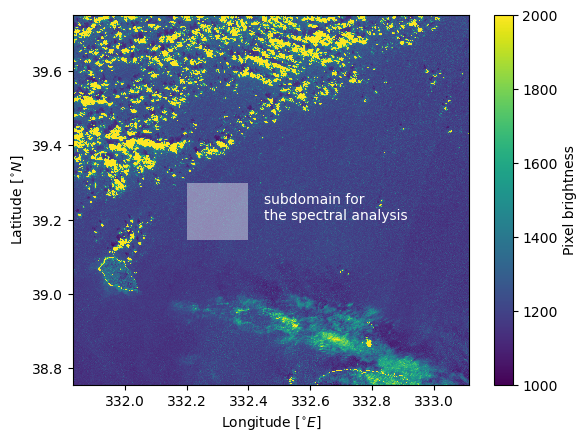

In [109]:
fig, ax = plt.subplots()
p1 = ax.pcolormesh(ds_satellite.longitude[::10], ds_satellite.latitude[::10], ds_satellite.B02_10m[::10, ::10], vmin = 1000, vmax = 2000)
ax.pcolormesh(sub_image.longitude, sub_image.latitude, sub_image.B02_10m, cmap = 'binary', vmin = 8000, vmax = 8001, alpha = .4)
ax.set_xlabel('Longitude [$^{\circ}E$]')
ax.set_ylabel('Latitude [$^{\circ}N$]')
plt.colorbar(p1, label = 'Pixel brightness')
ax.text(332.45, 39.2, 'subdomain for\nthe spectral analysis', color = 'w')



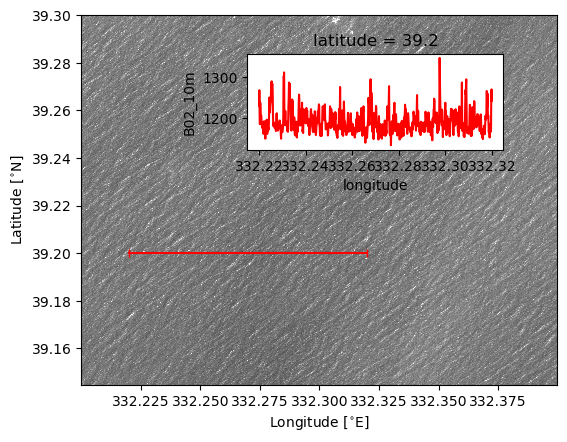

In [12]:
fig, ax = plt.subplots()
ax.pcolormesh(sub_image.longitude, sub_image.latitude, sub_image.B02_10m, cmap = 'binary_r', vmin = 1000, vmax = 1400)
ax.plot([longitude_transect_start, longitude_transect_end], [lat_0, lat_0], marker = '|', color = 'r')
ax.set_xlabel('Longitude [$^{\circ}$E]')
ax.set_ylabel('Latitude [$^{\circ}$N]')
ax_inset = fig.add_axes([.4, .6, .4, .2])
image_transect.B02_10m.plot(ax = ax_inset, color = 'r')
ax.set_aspect('equal', 'box')

Wave crests (bright pixels) and troughs (dark pixels) are clearly visible in the image. The dominant wavelength of this wave field can be estimated by using the pixel size (~10 m) and counting the number of crests over a given distance. As in the one-dimensional case, the key question is: which crests and troughs actually contribute to the dominant signal?

In addition, because the wave direction is not necessarily aligned with the satellite’s flight path, the wave field must be rotated into a reference frame aligned with the satellite track. Without this correction, the apparent wavelength may be artificially shortened or stretched by geometric projection effects.

A robust and accurate way to estimate the dominant wavelength is therefore to apply spectral analysis to the two-dimensional field.
Moreover, having a two-dimensional image of the wave field allows us to infer the directional properties of the observed wave system. In the example above, the waves are oriented along a NW–SE axis, but their directional spreading around this dominant direction remains unknown. These directional characteristics should emerge clearly in the two-dimensional spectrum.


### Spectral analysis

The philosophy of the spectral analysis remains the same. We are describing the variance of the signal in the Fourier space, but now in 2D!! We have a spatial description of the waves in the physical space $(x, y)$, so the spectrum will highlight the distribution of the wave energy along the "spatial frequencies" which are, in physics, the wavenumbers (units: 1/m). 

 - x$\rightarrow$ k$_{x}$

 - y$\rightarrow$ k$_{y}$

Let's remind that for a temporal signal:

 - t$\rightarrow$ f

Therefore:
brightness(x, y) $\rightarrow^{FT}$ E($k_x$, $k_y$), with E($k_x$, $k_y$) the two-dimensional spectrum.

For the method it remains that same as the one-dimensional analysis:

 - Define the sampling frequency $Fs$ -> $\propto 2\pi/dx$
   
 - Window the signal W(t)$\rightarrow$W(x, y)
   
 - Apply the fourier transform FFT$\rightarrow$FFT2D

   
 - normalization: $N_{t}$, df $\rightarrow$ $N_{x}$, $N_{y}$, $dkx$, $dky$

In [110]:
def two_dimensional_wave_spectrum(field_2D, dx, dy):
    """
    Purpose:
    --------
    Perform the spectral analysis of the 2D field with a pixel size of dx and dy
    Inputs:
    --------
    field_2D: The 2D MASS swath (dimensions ~ 2500 m| x 500 m)
    dx: pixel size in x
    dy: pixel size in y
    Outputs:
    --------
    phase_spec: The phase spectrum
    kx, ky the zonal and the meridional wavenumbers
    psd2D: The two-dimensional wave spectrum
    Z_shift: the intermediate wave spectrum
    dkx, dky: The wavenumber bins
    wc2xy: The 2D window correction
    """

    Nx = np.size(field_2D, 0)
    Ny = np.size(field_2D, 1)

    #-----------------------------
    ###### hanning
    #-----------------------------
    #1D  windows

    hanningx = 0.5 * (1-np.cos(2*np.pi*np.transpose(np.linspace(0,Nx-1,Nx))/(Nx-1)))
    hanningy = np.ones((1,Ny))*0.5 * (1-np.cos(2*np.pi*np.linspace(0,Ny-1,Ny)/(Ny-1)))

    hanningxy = np.matlib.repmat(hanningx,Ny,1)*np.matlib.repmat(np.transpose(hanningy), 1, Nx)

    # window correction factors
    wc2x = 1/np.mean(hanningx**2)
    wc2y = 1/np.mean(hanningy**2)
    wc2xy  = wc2x * wc2y

    #----------------------------
    #spatial frequency axis
    #----------------------------

    kx_max=(2*np.pi/dx)/2
    ky_max=(2*np.pi/dy)/2

    # step
    dkx=2*np.pi/(dx*(Nx//2)*2) #if odd-value data the max and min
    dky=2*np.pi/(dy*(Ny//2)*2)

    if np.mod(Nx,2)==0:
        #axes (for even-valued data, after fftshift...see example fft in MATLAB)
        kx=np.linspace(-kx_max, kx_max-dkx, Nx)
    else: #odd
        kx=np.linspace(-kx_max, kx_max, Nx)

    if np.mod(Ny,2)==0:
        #axes (for even-valued data, after fftshift...see example fft in MATLAB)
        ky=np.linspace(-ky_max, ky_max-dky, Ny)
    else: #odd
        ky=np.linspace(-ky_max, ky_max, Ny)

    dataW=np.zeros((np.shape(field_2D)))

    dkx = kx[3] - kx[2]
    dky = ky[3] - ky[2]

    #windowing
    new_data= field_2D - np.mean(field_2D[:]) # detrend
    dataW = new_data*hanningxy.T # windowing

    #--------------------------
    # Spectral analysis
    #--------------------------

    #Z_fft = np.fft.fft2(dataW, s=None)
    #Z_shift = np.fft.fftshift(Z_fft)/(Nx*Ny)
    Z_shift = np.fft.fftshift(np.fft.fft2(dataW))/ (Nx*Ny)

    # Calculate a 2D power spectrum
    psd2D_0 = np.abs(Z_shift)**2/(dkx*dky)
    phase_spec=np.arctan2(np.imag(Z_shift), np.real(Z_shift))

    psd2D = psd2D_0*wc2xy
    Ekxky = xr.DataArray(psd2D, [('kx', kx),  ('ky', ky)])

    ds = xr.Dataset({'kx': ('kx', kx),
                    'ky': ('ky', ky),
                    })

    ds['Ekxky'] = Ekxky
    ds = ds.set_coords(('kx', 'ky'))

    ds['Ekxky'].attrs['units'] = 'm^2/(rad/m)'

    ds['kx'].attrs['units'] = 'rad/m'
    ds['ky'].attrs['units'] = 'rad/m'

    return ds

def E_kxky_to_Ekth(E_kxky, kx, ky, number_of_dirs = 24):
    """
    Purpose: Interpolate the (kx, ky) spectrum onto directional-wavenumber spectrum
    inputs:
    E_kxky: the 2D wavenumber spectrum
    kx: the horizontal wavenumber (1D)
    ky: the vertical wavenumber (1D)
    
    outputs:
    dirspec: wavenumber-direction spectrum
    dd_new, kk_new: 2D dir-wavenumber axes
    """
    nk = np.size(kx)
    dkx = kx[1]-kx[0]
    k_new = np.linspace(0, np.amax(kx), nk)
    # Number of directions that you want on the polar grid
    nd = number_of_dirs
    dd = 2*np.pi/nd
    # Direction axis on the polar grid ranging from -pi to pi with dd increments
    d_new = np.arange(-np.pi, np.pi, dd)
    # Polar grid to interpolate onto
    # d_new = d_new0[number_of_dirs//2:]

    kk_new, dd_new = np.meshgrid(k_new, d_new)

    dirspec = xr.DataArray(np.zeros(dd_new.shape) * np.nan, [('theta', d_new),  ('K', k_new)])
    
    # Be sure working with a good xarray format
    Ekxky = xr.DataArray(E_kxky.T, dims=['ky', 'kx'], coords={'ky':ky, 'kx':kx})

    for i in range(nd):
        di = dd_new[i][0]
        ki = k_new
        kx_int = xr.DataArray(ki*np.cos(di), dims='K')
        ky_int = xr.DataArray(ki*np.sin(di), dims='K')
        dirspec[i, :] = Ekxky.interp(ky=ky_int, kx=kx_int)

    #here we're multiplying by the jacobian of the transformation from cartesian to polar
    dirspec = dirspec * kk_new 
    
    return dirspec, dd_new, kk_new

### Start the two-dimensional spectral analysis

In [116]:
dx = 10
dy = 10
data_for_fourier_analysis = sub_image.B02_10m[::-1, :].values  # The first dimension is flipped because the satellite has a descending track (latitudes decreases)
ds_spec_2d = two_dimensional_wave_spectrum(data_for_fourier_analysis, dx, dy) # Apply the 2D spectral analysis

### Plot the wavenumber spectrum

Text(0, 0.012566370614359173, '500 m')

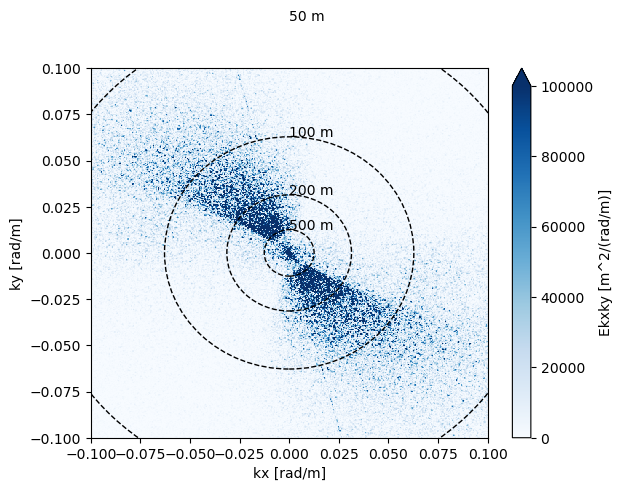

In [112]:
#############,
#---White circles
#############
radius_050m=2*np.pi/(50.)
radius_100m=2*np.pi/(100.)
radius_200m=2*np.pi/(200.)
radius_500m=2*np.pi/(500.)


fig, ax = plt.subplots()
ds_spec_2d.Ekxky.T.plot(vmin = 0, vmax = 100_000, cmap = 'Blues')
plt.xlim([-.1, .1])
plt.ylim([-.1, .1])
circle1 = plt.Circle((0.0, 0.0), radius_050m, color='k',transform=ax.transData._b,linestyle='--',fill=False)
ax.add_patch(circle1)
circle2 = plt.Circle((0.0, 0.0), radius_100m, color='k',transform=ax.transData._b,linestyle='--',fill=False)
ax.add_patch(circle2)
circle3 = plt.Circle((0.0, 0.0), radius_200m, color='k',transform=ax.transData._b,linestyle='--',fill=False)
ax.add_patch(circle3)
circle4 = plt.Circle((0.0, 0.0), radius_500m, color='k',transform=ax.transData._b,linestyle='--',fill=False)
ax.add_patch(circle4)
plt.text(0,radius_050m,'50 m',color='k')
plt.text(0,radius_100m,'100 m',color='k')
plt.text(0,radius_200m,'200 m',color='k')
plt.text(0,radius_500m,'500 m',color='k')

A diagonal line appears across the wavenumber domain, which in physical space would imply the presence of a highly energetic signal spanning all scales (from 
$\mathcal{O}$(10) km down to ~20 m). Such broadband, scale-invariant energy is physically unrealistic. The wave-field image shown above shows a discontinuity, most likely caused by the overlap region between two different detectors onboard Sentinel-2. A simple way to remove this artifact is to work with an image that does not include this sensor-transition area.

In [113]:
sub_image_cor = sub_image.isel(longitude = slice(0, 500), latitude =slice(0, 500))

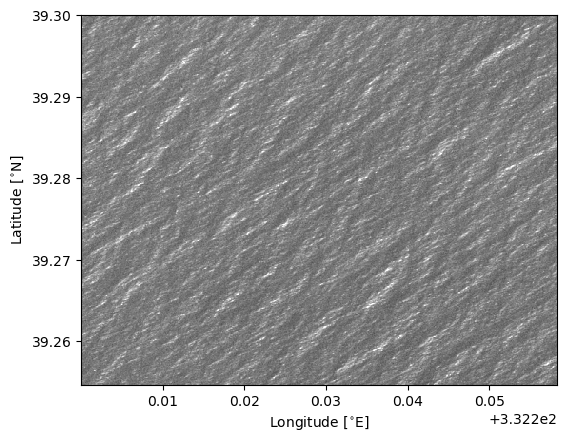

In [115]:
fig, ax = plt.subplots()
ax.pcolormesh(sub_image_cor.longitude, sub_image_cor.latitude, sub_image_cor.B02_10m, cmap = 'binary_r', vmin = 1000, vmax = 1400)
ax.set_xlabel('Longitude [$^{\circ}$E]')
ax.set_ylabel('Latitude [$^{\circ}$N]')
ax.set_aspect('equal', 'box')

In [121]:
ds_spec_2d = two_dimensional_wave_spectrum(sub_image_cor.B02_10m[::-1, :], dx, dy)

(-0.1, 0.1)

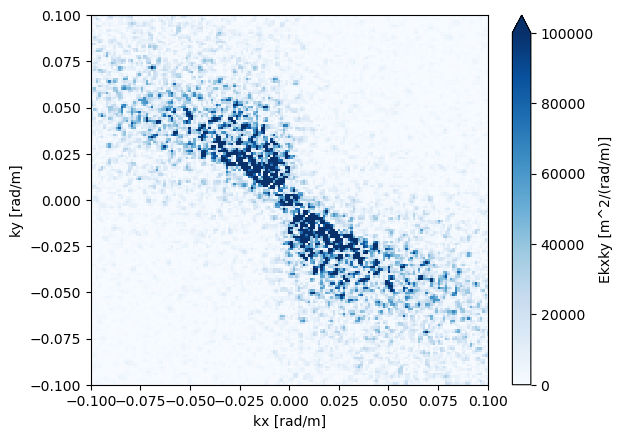

In [122]:
fig, ax = plt.subplots()
ds_spec_2d.Ekxky.T.plot(vmin = 0, vmax = 100_000, cmap = 'Blues')
plt.xlim([-.1, .1])
plt.ylim([-.1, .1])


### Switch from Carthesian to Polar coordinate

If we spot the maxima of the energy we can infer the dominant wavenumbers both along both $k_x$ and $k_y$. If we know the component of the wavenumber vector, we can determine the module of the dominant wave wavenumber (and therefore the wavelength) as well as the dominant direction.

Or we can transform the spectrum from the carthesian frame of coordinate to the polar frame of coordinate.

$$E(k_x, k_y) \rightarrow E(k, \theta)$$

Behind the transformation there is a matricial operator that I won't go through but feel free to check in the code.

In [150]:
dirspec, dd_new, kk_new = E_kxky_to_Ekth(ds_spec_2d.Ekxky.values, ds_spec_2d.kx.values, ds_spec_2d.ky.values, number_of_dirs = 48) # switch the frame of coordinate
dth = np.diff(dd_new[:,0])[0]# the directional step

Text(0.5, 0, 'Wavelength [m]')

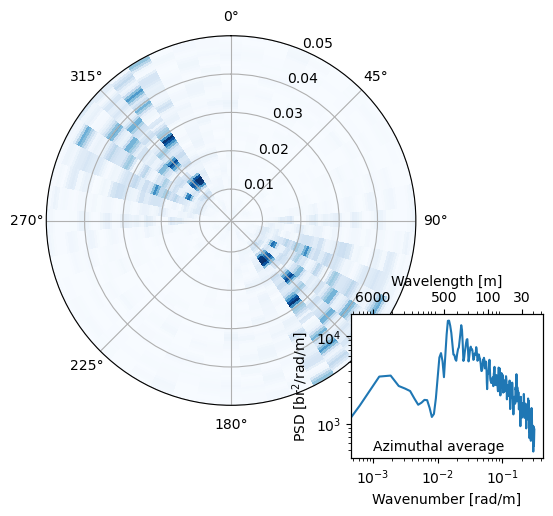

In [245]:
fig, ax = plt.subplots(subplot_kw = {'projection':'polar'})
ax.pcolor(dd_new, kk_new, dirspec, cmap = 'Blues')
ax.set_ylim([0.0018, 0.05])
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax_inset = fig.add_axes([.7, 0, .3, .3])
ax2 = ax_inset.twiny()
ax_inset.loglog(kk_new[0,:], np.nansum(dirspec, axis = 0)*dth)
ax2.loglog(kk_new[0,1:], np.nansum(dirspec[:,1:], axis = 0)*dth, alpha = 0)
ax2.set_xticks([0.001, 0.0127, 0.06, 0.2])
ax2.set_xticklabels( ['6000', '500', '100', '30'])

ax_inset.set_xlabel('Wavenumber [rad/m]')
ax_inset.set_ylabel('PSD [br$^{2}$/rad/m]')
ax_inset.text(1/1000, 500, 'Azimuthal average')
ax2.set_xlabel('Wavelength [m]')

The zeniths provide the wave wavenumbers and the azimuths the wave directions. By integrating the wave spectrum along direction yields the, what we call the omnidirectional spectrum $E(k)$.

In [91]:
idp_theta, idp_k = np.where(dirspec == np.amax(dirspec)) # Get dominant wave parameters

In [148]:
print(f'The peak direction is equal to {(np.pi+dd_new[idp_theta, 0][0])*180/np.pi} deg')
print(f'The peak wavelength is equal to {(2*np.pi/kk_new[0, idp_k][0])} m')

The peak direction is equal to 322.49999999999966 deg
The peak wavelength is equal to 400.80321285140565 m


The computed wave spectrum appears very noisy. To reduce this noise, one can apply a Welch-type approach by dividing the image into several overlapping boxes and averaging their individual spectra, rather than relying on a single window

Using Sentinel-2 imagery, we can extract information on the wavefield’s dominant wavelength and direction. However, because the satellite does not measure the actual sea-surface elevation but only the brightness intensity of each pixel resulting from the relected sunlight, we cannot reliably estimate wave parameters such as the significant wave height ($H_s$). For instance, a naïve application of the elevation-based formulas yields an apparent $H_s$ ~ 119 m which is clearly non-physical.